# Introduction
The task description is a follows:
- By only using file "data.npy", send back a notebook that produces a csv file that includes the correct data entries for the first 5000 "city, state" pairs.

In [1]:
import numpy as np
import pandas as pd

#specify file path
file_path = 'data.npy'

data = np.load(file_path, allow_pickle=True)

We shall first read the file and inspect the data

In [2]:
## print the first n lines
for i in range(10):
    line = str(data[i])
    sline = line.split(",")
    print("Array contents of line " + str(i) + ":", sline[0],"," , sline[1])

Array contents of line 0: livonia center ,  ny
Array contents of line 1: hanyes ,  nd
Array contents of line 2: big bay ,  mi
Array contents of line 3: central gardens ,  tx
Array contents of line 4: mcintosh ,  fl
Array contents of line 5: louisville ,  al
Array contents of line 6: wilson ,  ar
Array contents of line 7: llano del medio ,  nm
Array contents of line 8: antonito ,  co
Array contents of line 9: pleasnt pain ,  oh


As can be seen, the file contains "city,state" pairs where the states are provided using what seems like lower case United States Postal Service (USPS) 2-letter codes as shown below
- livonia center ,  ny
- hanyes ,  nd
- big bay ,  mi
- central gardens ,  tx
- mcintosh ,  fl
- louisville ,  al

It should be noted that identifying some of the inaccuracies within the data would require comprehensive knowledge of U.S. geography, including official city names and their corresponding states. Several sources can be used to aid in this endavour, e.g. 

- U.S. Census Bureau data
- United States Postal Service (USPS) city-state listings; and
- Geographic Names Information System (GNIS)

A corresponding library can also be used, e.g., country_state_city (see: https://pypi.org/project/country-state-city/) which contains mappings between cities and states in various countries, and this shall be the case in the remainder of this notebook. 


---
# Processing
The results of two analytical approaches designed to resolve inaccuracies in the first 5000 line of the given city-state pairs are presented in the sequal, via:
 - Search-Based Matching – a deterministic approach that searches for the best match in a reference dataset (using the library mentioned above); and 
 - Machine Learning Classification – a predictive approach that uses a trained model to classify and infer the most likely state for a given city.

The goal is to evaluate the effectiveness of each method. 

### Search-Based Approach
The search-based method relies on string similarity techniques to identify the closest match for a given city-state pair in a reference dataset. The process involves:
 - Preprocessing: Normalizing input strings by converting to uppercase and removing trailing spaces.
 - Similarity Scoring: Computing similarity scores using a bespoke algorithm to determine exact or 'fuzzy' matches between given and target city-state combinations; and 
 - Ranking and Selection: Ranking candidate matches based on combined city and state similarity scores and selecting the highest-ranked match as the corrected pair.

This approach is rule-based and interpretable, making it suitable for moderate error rates (as seem to largely be the case in the data set). However, its performance may degrade when city names are severely misspelled or when state codes are missing or ambiguous. It also has poor time complexity as, in the worst case, it would search through all 19000+ city-state combinations for each of the 5000 city-state pairs (i.e., approximately O(5000 * 20000)). It is therefore not advisable to reproduce the output from this section (i.e., via a call to the function *process_city_state_matches(read_from_file=True)* at the end with the parameter set to *False*) as this process can take upwards of 36 hours to terminate, depending on the machine.

Note, it is also possible to use a dictionary but no significant improvement in performance was noted via this approach. 

In [3]:
from country_state_city import  City, State 

# define some constants for thresholds and parameters
MATCH_THRESHOLD_MIN = 83.0
PARTIAL_MATCH_THRESHOLD_MAX = 95.0
PARTIAL_MATCH_CUTOFF = 90.5
STRING_MATCH_LOOK_AHEAD_LIMIT = 3  
CITY_STATE_MATCH_LIMIT = 5000
MANUAL_MATCH_RESULT_FILE = 'data_output.csv'


# calculate the proportion of the test string that exist in the target string
def string_match_percent(test_string,target_string,target_string_len):
    if test_string == target_string:
        return 100.0
    match_count = 0.0
    
    #    
    for i, char in enumerate(test_string)  :
        match_index = i
        for j in range(match_index,target_string_len):
            if char == target_string[j]:
                match_count += 1
                match_index = j
                break
            if j > match_index + STRING_MATCH_LOOK_AHEAD_LIMIT:
                break
    
    match_percent = (match_count / target_string_len) * 100.0 
    match_result = match_percent if j >= i else min(PARTIAL_MATCH_CUTOFF, match_percent) 
    return match_result

# Function to get city info in a state
def get_city_state_match_proportion(city_to_find, state):
    found_proportion = 0.0
    
    cities_in_state = City.get_cities_of_state('US', state)
    for city in cities_in_state:
        # check for matched characters percentage
        city_lower = city.name.lower().strip()    
        match_proportion = string_match_percent(city_to_find, city_lower,len(city_lower))   
        if match_proportion > found_proportion:
            found_proportion = match_proportion
            if found_proportion > PARTIAL_MATCH_THRESHOLD_MAX:
                break
    return found_proportion

def get_city_info_all_states(match_limit=CITY_STATE_MATCH_LIMIT):
    found_list = []
    for i in range(match_limit):
        line = str(data[i])
        sline = line.split(",")
        city = str(sline[0]).lower().strip()
        state = str(sline[1]).upper().strip()        
        found_proportion = get_city_state_match_proportion(city, state)
        if found_proportion >= PARTIAL_MATCH_CUTOFF:
            found_list.append((city,state,state,found_proportion))
        else:
            states_in_th_us = State.get_states_of_country('US')
            found_in_other_state_match_value = found_proportion
            found_state = state          
            for st in states_in_th_us:
                new_state = st.iso_code.upper().strip()
                if new_state != state:
                    other_state_match_value = get_city_state_match_proportion(city, new_state)
                    if (other_state_match_value > found_in_other_state_match_value):
                        found_in_other_state_match_value = other_state_match_value
                        found_state = new_state
                        if found_in_other_state_match_value > PARTIAL_MATCH_THRESHOLD_MAX:
                            break
            found_list.append((city,state,found_state,found_in_other_state_match_value)) 
            if found_state != state and i%10 == 0:
                print(f"{i}.\t Found city/town '{city}' in state: {found_state} instead of {state} with match proportion: {found_in_other_state_match_value:.2f}%")
            
    return found_list

#read the city info and process the matches
def process_city_state_matches(read_from_file=True,match_limit=CITY_STATE_MATCH_LIMIT):
    if read_from_file:
        df = pd.read_csv(MANUAL_MATCH_RESULT_FILE, encoding='utf-8')
        return df
    else:
        lst = get_city_info_all_states(match_limit=match_limit)
        df = pd.DataFrame(columns=['OriginalCityStateID','NewCityStateID','City', 'OriginalState','NewState','MatchValue'])
        for i, (city, state, found_state, match_proportion) in enumerate(lst):
            original_city_state_id = "".join((city + state.lower()).split())
            new_city_state_id = "".join((city + found_state.lower()).split())
            df.loc[i] = [original_city_state_id, new_city_state_id, city, state, found_state, match_proportion]  
        # print the dataframe to a csv file
        df.to_csv(MANUAL_MATCH_RESULT_FILE, encoding='utf-8', index=False, header=True)
    return df
#'''
df = process_city_state_matches(read_from_file=True) 

# Machine Learning Approach

The machine learning approach treats the problem as a classification task. A model is trained on the reference dataset to predict the correct state given a city name. The workflow includes:
 - Feature Engineering: Transforming city names into numerical representations using character-level embeddings or TF-IDF vectors.
 - Model Training: Training a supervised learning model (e.g., in this case a Logistic Regression classifier) to classify the state based on city features.
 - Inference: For each input pair, the model predicts the most likely state. 

This approach is robust to misspellings and incomplete data. Random distortions to the training data are added to improve the model’s ability to learn patterns from various city-state associations. It is noted that a robust classifier would require sufficient training data (e.g., including observed distortions learnt from a sample of the test data) so, given that this task is a demonstrator, only a limited number of random distortions were added to the training data.

### Creating City-State pairs for training

In [4]:
#import pandas as pd

CITY_AND_STATE_FILENAME = 'cities_and_states.csv'
STATES_ONLY_FILENAME = 'states_only.csv'

# print all states and cities for training and validation
def get_all_cities_and_states ():
    number_of_cities = 0
    cities_and_states = {}
    for states_in_us in State.get_states_of_country('US'):
        cities_in_state = City.get_cities_of_state('US', states_in_us.iso_code)
        number_of_cities += len(cities_in_state)
        for city in cities_in_state:
            city_name = city.name.lower()
            state_iso = states_in_us.iso_code.lower()
            city_state_id = "".join((city_name + state_iso).split())
            state_name = states_in_us.name.lower()
            # check if "b" is none or not.
            if cities_and_states.get(city_state_id) == None:
                cities_and_states[city_state_id] = (city_name, state_iso, state_name)
    return (number_of_cities,cities_and_states)

# get all cities and states
(number_of_cities,cities_and_states) = get_all_cities_and_states()
print(f"  Number of cities: {number_of_cities} \t Number of records added: {len(cities_and_states)}")
df1 = pd.DataFrame(columns=['CityStateID','City', 'ISO_Code', 'State'])
for i, (city_state_id, (city_name, state_iso, state_name)) in enumerate(cities_and_states.items()):
    df1.loc[i] = [city_state_id, city_name, state_iso, state_name]

# create a states dataframe
dfStates = pd.DataFrame(columns=['State','StateID','ISO_Code'])
dfStates[['State','ISO_Code']] = df1[['State','ISO_Code']].drop_duplicates().values

dfStates['StateID'] = dfStates.index
dfStates.to_csv(STATES_ONLY_FILENAME, encoding='utf-8', index=False, header=True)

df1 = pd.merge(df1, dfStates, how="inner", on=["State"])

#print the dataframe to a csv file
df1.to_csv(CITY_AND_STATE_FILENAME, encoding='utf-8', index=False, header=True)

  Number of cities: 19817 	 Number of records added: 19815


### Building the classifier for city-state pairs 
This process takes at least 10 minutes to run (depending on the machine) so, again, it is advisable not to set the *refit* flag to *True* in *finaldf = get_fitted_model(refit=False)* below

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
#from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

import random
import string

import warnings
warnings.filterwarnings('ignore')

# set random seed for reproducibility
random.seed(30)

AUGMENTED_CITY_AND_STATE_FILENAME = 'augmented_cities_and_states.csv'

le = LabelEncoder()

# ----------------------------
# Synthetic typo augmentation 
# ----------------------------
def random_typo(s, p=0.5):
    """
    Create a single noisy variant of s with probability p of applying one random edit.
    Edits: deletion (x2), insertion, or substitution, with the deletion operation twice 
    as likely as insertion or substitution.
    """
    if not s or random.random() > p:
        return s

    s_list = list(s)
    ops = ["del1", "del2", "sub", "ins"]
    op = random.choice(ops)

    if op == "del1" and len(s_list) > 1:
        i = random.randrange(len(s_list))
        del s_list[i]
    elif op == "del2" and len(s_list) > 1:
        i = random.randrange(len(s_list))
        del s_list[i]
    elif op == "ins":
        i = random.randrange(len(s_list) + 1)
        s_list.insert(i, random.choice(string.ascii_lowercase))
    elif op == "sub" and len(s_list) > 0:
        i = random.randrange(len(s_list))
        s_list[i] = random.choice(string.ascii_lowercase)

    return "".join(s_list)


def augment_dataframe(df, n_aug=3):
    rows = []
    for _, r in df.iterrows():
        base = r["City"]
        state = r["StateID"]
        rows.append({"City": base, "StateID": state})
        for _ in range(n_aug):
            rows.append({"City": random_typo(base, p=0.95), "StateID": state})
    return pd.DataFrame(rows)


#------------------------------------------------------------------------------------
# Build and train the model (Pipeline with TF-IDF + Logistic Regression Classifier)
#-------------------------------------------------------------------------------------
clf = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(analyzer="word", stop_words='english', min_df=1)),
    ("logreg", LogisticRegression(max_iter=200, n_jobs=None, class_weight="balanced"))
])

# Fit the model to the augmented data
def augment_and_fit_model(n_aug_in=3):
    aug = augment_dataframe(df1, n_aug=n_aug_in)
    X_train,  y_train = aug['City'], aug['StateID']
    y_train_enc = le.fit_transform(y_train)
    clf.fit(X_train, y_train_enc)


# ---------------------------------------------
# Inference helper with confidence, top-k
# ---------------------------------------------
def predict_state(city_name: str, k=3):
    proba = clf.predict_proba([city_name])[0]
    top_idx = np.argsort(proba)[::-1][:k]
    top_states = le.inverse_transform(top_idx)
    top_scores = proba[top_idx].tolist()
    best_state, best_score = top_states[0], float(top_scores[0])
    result = {
        "MlInputCity": city_name,
        "MlPredictedState": dfStates['ISO_Code'].iloc[best_state],
        "MlConfidence": best_score
    }
    return result

#--------------------------------------------
# Get the fitted model and predictions
#--------------------------------------------
def get_fitted_model(refit = False):
    if refit:
        augment_and_fit_model(n_aug_in=10)
        ## get the ML-based predictions
        inputStates = df['City'].unique()
        mldf = pd.DataFrame.from_dict([ predict_state(cityname, k=3) for cityname in inputStates.tolist() ])

        # join the results with the original dataframe
        tempdf = pd.merge(df, mldf, how="inner", left_on=["City"], right_on=["MlInputCity"])
        tempdf['MlPredictedState'] = tempdf['MlPredictedState'].str.upper()
        return  tempdf
    else:
        tempdf = pd.read_csv(AUGMENTED_CITY_AND_STATE_FILENAME, encoding='utf-8')
        return tempdf
    #
finaldf = get_fitted_model(refit=False)

# view the first 10 rows of the final dataframe
print(finaldf.head(10))

#print the final dataframe to a csv file for analysis
finaldf.to_csv(AUGMENTED_CITY_AND_STATE_FILENAME, encoding='utf-8', index=False, header=True)


  OriginalCityStateID    NewCityStateID             City OriginalState  \
0     livoniacenterny   livoniacenterny   livonia center            NY   
1            hanyesnd          hanyesak           hanyes            ND   
2            bigbaymi          bigbayal          big bay            MI   
3    centralgardenstx  centralgardenstx  central gardens            TX   
4          mcintoshfl        mcintoshnm         mcintosh            FL   
5        louisvilleal      louisvilleco       louisville            AL   
6            wilsonar          wilsonny           wilson            AR   
7     llanodelmedionm   llanodelmedioar  llano del medio            NM   
8          antonitoco        antonitoco         antonito            CO   
9       pleasntpainoh     pleasntpainca     pleasnt pain            OH   

  NewState  MatchValue      MlInputCity MlPredictedState  MlConfidence  
0       NY   90.500000   livonia center               CT      0.160572  
1       AK   83.333333           hanyes

# Analysis and Conclusion

Here is some simple analysis on the results

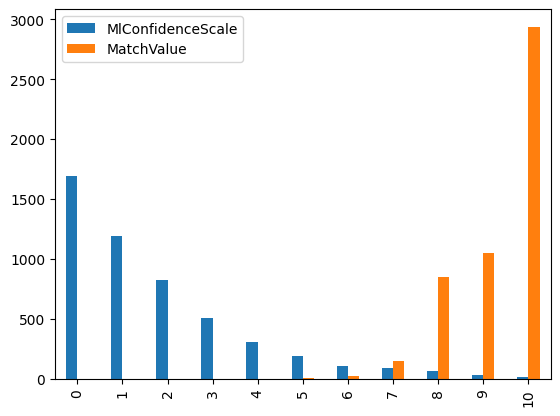

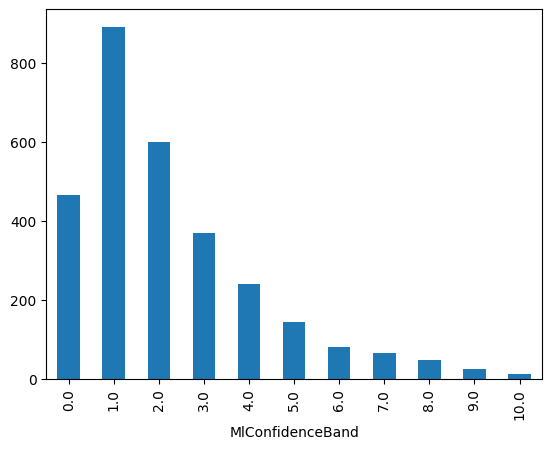

In [6]:

import matplotlib.pyplot as plt

finaldf = pd.read_csv(AUGMENTED_CITY_AND_STATE_FILENAME, encoding='utf-8')

finaldf['MlConfidenceScale'] = finaldf['MlConfidence'] * 100.0

finaldf['SearchBand'] = round(finaldf['MatchValue'] / 10.0)
finaldf['MlConfidenceBand'] = round(finaldf['MlConfidenceScale'] / 10.0)

#flag where the search did not change the state
searchconditions = [
                    (finaldf['OriginalState'] == finaldf['NewState']),
                    (finaldf['OriginalState'] != finaldf['NewState'])
                   ]
finaldf['SearchNoChange'] = np.select(searchconditions, [1, 0]) 


#flag where the ML did not change the state
mlconditions = [
                    (finaldf['OriginalState'] == finaldf['MlPredictedState']),
                    (finaldf['OriginalState'] != finaldf['MlPredictedState'])
                ]
finaldf['MlNoChange'] = np.select(mlconditions, [1, 0])

#flag where the ML and search gave same results 
searchmlsame = [
                    (finaldf['MlPredictedState'] == finaldf['NewState']),
                    (finaldf['MlPredictedState'] != finaldf['NewState'])
               ]
finaldf['SearchMLSame'] = np.select(searchmlsame, [1, 0]) 

#compare the frequency of match bands
mlConfidence_groups  = finaldf.groupby('MlConfidenceBand')['MlConfidenceScale'].count()
searchConfidence_groups  = finaldf.groupby('SearchBand')['MatchValue'].count()

# join the results with the original dataframe
tempdf = pd.merge(mlConfidence_groups, searchConfidence_groups, how="left", left_on=["MlConfidenceBand"], right_on=["SearchBand"])
tempdf.plot(kind='bar')
plt.show()


# Plot the ML match probability distribution for those with 100% match confidence from the search-based method
fdf = finaldf[finaldf['MatchValue'] > 99.9]
fdfml_groups  = fdf.groupby('MlConfidenceBand')['MlConfidenceScale'].count()
fdfml_groups.plot(kind='bar')
plt.show()

We see poor match probabilities from the ML approach when compared with scores from the search-based approach, even for those cases where the search-based approach gave a 100% match (first and second plots above, respectively). This is very likely due to the training set used to train the classifier. For instance, and as was mentioned above, the training data can be augmented by further distortions learnt from a sample of the test data, which is likely to improve the power of the classifier. A larger training set would, subsequently, be more amenable to other classifiers (e.g., neural network), which are likely to be more robust and produce results that are better aligned with, or better then, the search-based approach.

### Conclusion

Search-based and machine-learning approaches were used to identify correct data entries for the first 5000 "city, state" pairs in the “data.npy" file provided. 

 - Accuracy: The search-based approach significantly outperforms the machine learning model. If the matches with 100% accuracy in the search-based approach are used as a test set, we see that the machine learning model is only 50% accurate (note, 60% accuracy was achieved using a Support Vector Machine classifier, but the classification process takes considerably longer to run than the Logistic Regression approach presented). This is most likely due to the limited number of distortions made to the training data as well as the fact that these distortions were randomly made. It is very likely that a machine learning model would be significantly better if more tailored distortions are made and other learning algorithms (e.g., a neural network) are employed.
 - Interpretability: The search-based method is more transparent, as corrections are based on explicit similarity scores. The machine learning approach is less interpretable, especially since there is significant variation in match probabilities even in cases where the matches are correct and the majority of correct matches have low match probabilities (see second plot above).
 - Scalability: The machine learning model potentially scales better for large datasets once trained, whereas the search-based method quickly becomes computationally expensive for large reference sets (see complexity note earlier)
 - Error Types: Search-based matching can struggle with severe misspellings and missing codes, while machine learning can infer states better, but may misclassify cities with multiple possible states (e.g., “springfield”).

In a practical setting, a hybrid approach could leverage the strengths of both methods. For instance, search-based matching can be used to identify 100% matches and those with minor distortions (e.g., names of length > 10 with one missing letter) while a machine-learning approach can be applied to learning the remaining, more complex cases.

It should be noted that that the matches discovered depend on the information provided in the ‘country_state_city’ library used (see: https://pypi.org/project/country-state-city/), so matches are subject to information found within said file. 
